## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- Aaron Soekiatno: Conceptualization, Software, Visualization, Analysis
- Ezra Hong:  Background research, Analysis, Data curation
- Dylan Dwight: Project administration, Experimental investigation, Writing - original draft
- Chon: Software, Methodology, Data curation
- Mai Tamura: Background research, Writing - original draft, Writing - review & editing

# Research Question

Research Question: Do teams that win the first set have a significantly higher chance of winning the match, and how does early-set momentum correlate with final match results? Does this pattern continue in the NCAA tournament of the same year?

Metrics/Variables:
Outcome: Match result (win/loss)
Key predictor: First set result (win/loss)
Additional variables: Second set result, set score margin, match format (best of 3)

Analysis Type: This is a descriptive and exploratory analysis task. We will calculate win probabilities for teams based on whether they won or lost the first set. Using bar charts, pie charts, and conditional probability tables, we will visualize how first-set winners perform in the overall match. We can extend the analysis to see if winning the first two sets nearly guarantees victory. The final deliverable will be a dashboard showing momentum patterns and win probabilities at different stages of a match.

## Background and Prior Work

Match competitiveness is a key theme in volleyball analytics. Recent analytics has emphasized measurable indicators of competitiveness—such as point differentials, number of sets played, and home-court effects-to understand how closely intense matches turn out.

Because matches are played as best-of-five sets in certain leagues, early outcomes do not guarantee final results, especially in matches extending beyond three sets. Research in collegiate athletics has also examined the role of home-court advantage in shaping competitive outcomes. Studies across NCAA sports have found that home teams benefit not only in win probability but also in scoring margins. In volleyball specifically, home advantage has been linked to factors such as crowd support, familiarity with the court conditions, and reduced traveling. However, less research has focused on how home or away status affects match competitiveness—particularly in matches that extend beyond three sets.

Additionally, sports analytics literature increasingly uses point differential as a primary indicator of competitiveness. Smaller scoring margins across sets are widely interpreted as signals of evenly matched teams. Analyses in basketball, soccer, and volleyball have demonstrated that attendance and external factors can influence these margins, potentially increasing or decreasing competitive balance.

Our project builds on this prior work by shifting the focus to strictly competitiveness and results of matches that extend to 3 sets. Specifically, we examine whether winning the first set meaningfully predicts match outcomes in extended matches, and whether away teams that win the first set experience more competitive matches, as measured by smaller point differentials when compared to home teams. By concentrating on measurable indicators of competitive intensity, our project aims to provide a clearer understanding of how early advantages shape the competitiveness of NCAA women’s volleyball matches, especially if they are an away team.

# Hypothesis


Hypothesis: Among the 2019 NCAA women's volleyball dataset for matches that extend past 3 sets, the team that won the first set will only have a slightly higher chance to win the match. Additionally, when the away team wins the first set, the match will have a smaller overall point differential, indicating greater competitiveness.

Reasoning: Winning the first set as the away team will likely increase competitiveness and pressure on the opposing team. Additionally, the team that wins the first set has demonstrated early that they can outperform their opponent, which may reflect a  skill advantage that carries through the rest of the match.

## Data

### Data overview

For this project we are analyzing match data from the 2019 NCAA Division I women's volleyball season. Each row of the data set represents a match between two teams and includes information like the teams that played, the location, the points scored each set by both teams, the number of sets won by each team, the match winner, and the attendance.

The dataset contains 4,958 matches and 19 variables. Important variables include the set scores for both teams, the number of sets won by each team, the match location, and the final match outcome. From these variables we can determine which team wont he first set, how many sets were played in the match, and the overall competitveness of the match by calculating the point differentials.

We also looked at a second data set that has the same variables and metrics as our first one, but of matches played in the 2019 NCAA tournament.

Because our research question focuses on matches that extend beyond three sets, we created a new variable called 'total_sets' by summing the sets won by both teams. This way we could filter the dataset to include only matches where 'total+sets >= 4'. This subset represents matches that went to four or five sets and are therefore more competitive.

The cleaned dataset used for analysis contains 531 matches and 20 variables after filtering and preprocessing. We are then going to compare our results with the first dataset to the matches in the 2019 NCAA tournament which we will get data from the second dataset.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-all-matches.csv', 'filename':'vball_matches_season.csv'},
    { 'url': 'https://raw.githubusercontent.com/larget/stat-240-case-studies/refs/heads/master/data/vb-division1-2019-ncaa-tourney.csv', 'filename':'vball_matches_tournament.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  2.42it/s]         

Successfully downloaded: vball_matches_season.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  3.21it/s]             

Successfully downloaded: vball_matches_tournament.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
import pandas as pd
df = pd.read_csv('data/00-raw/vball_matches_season.csv')
df = df.dropna(subset=['site'])
df['total_sets'] = df['sets_1'] + df['sets_2']
df_competitive = df[df['total_sets'] >= 4]
df.head()

,date,team1,team2,site,s1_1,s1_2,s1_3,s1_4,s1_5,sets_1,s2_1,s2_2,s2_3,s2_4,s2_5,sets_2,winner,loser,attendance,total_sets
1,2019-08-30,South Carolina St.,Texas Southern,"@Montgomery, Ala.",25.0,25.0,12.0,18.0,17.0,2,21.0,20.0,25.0,25.0,19.0,3,Texas Southern,South Carolina St.,0.0,5
3,2019-08-30,SIUE,UC Riverside,"@DeKalb, IL",17.0,20.0,18.0,NaN,NaN,0,25.0,25.0,25.0,NaN,NaN,3,UC Riverside,SIUE,75.0,3
4,2019-08-30,Temple,Fairfield,"@Baltimore, MD",25.0,25.0,25.0,NaN,NaN,3,20.0,15.0,13.0,NaN,NaN,0,Temple,Fairfield,0.0,3
6,2019-08-30,Niagara,Stetson,"@Boca Raton, FL",17.0,14.0,16.0,NaN,NaN,0,25.0,25.0,25.0,NaN,NaN,3,Stetson,Niagara,0.0,3
7,2019-08-30,Howard,Hartford,"@Washington, DC",25.0,25.0,25.0,NaN,NaN,3,23.0,23.0,20.0,NaN,NaN,0,Howard,Hartford,0.0,3


### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [4]:
df2 = pd.read_csv("data/00-raw/vball_matches_tournament.csv", sep=None, engine="python")

df2 = df2.dropna(subset=["site"])
df2["total_sets"] = df2["sets_1"] + df2["sets_2"]
df2_competitive = df2[df2["total_sets"] >= 4]

df2.head()

,date,team1,team2,site,s1_1,s1_2,s1_3,s1_4,s1_5,sets_1,s2_1,s2_2,s2_3,s2_4,s2_5,sets_2,winner,loser,attendance,total_sets
0,2019-12-05,Florida St.,UCF,"@Gainesville, FL (DI WVB Championship)",19,25,25,18.0,8.0,2,25,20,20,25.0,15.0,3,UCF,Florida St.,560,5
1,2019-12-05,Texas St.,UC Santa Barbara,"@Austin, TX (DI WVB Championship)",21,21,25,14.0,NaN,1,25,25,20,25.0,NaN,3,UC Santa Barbara,Texas St.,3532,4
2,2019-12-05,Oklahoma,Rice,"@College Station, TX (DI WVB Championship)",18,22,19,NaN,NaN,0,25,25,25,NaN,NaN,3,Rice,Oklahoma,1353,3
3,2019-12-05,Samford,Louisville,"@Bowling Green, KY (DI WVB Championship)",21,12,22,NaN,NaN,0,25,25,25,NaN,NaN,3,Louisville,Samford,0,3
4,2019-12-05,Alabama St.,10 Florida,DI WVB Championship,10,16,20,NaN,NaN,0,25,25,25,NaN,NaN,3,10 Florida,Alabama St.,2022,3


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - Does winning the first set increase probability of winning the match?

This computes who won set 1, who won the match, the probability out of the cases that the first-set winner won the match, and it does this separately for the cases of regular season matches and the tournament ones.


EDA 1 — Regular Season
P(first set winner wins match) = 0.5913


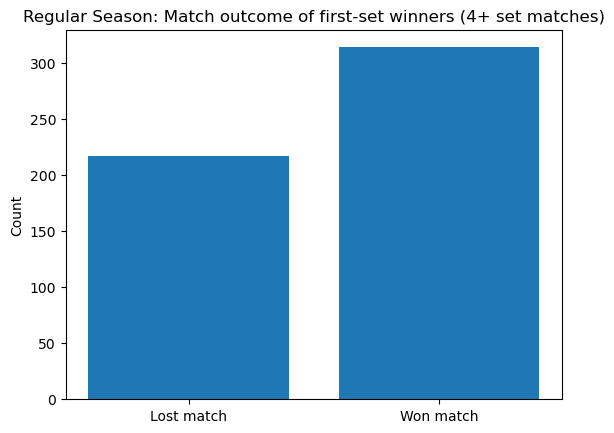


EDA 1 — Tournament
P(first set winner wins match) = 0.52


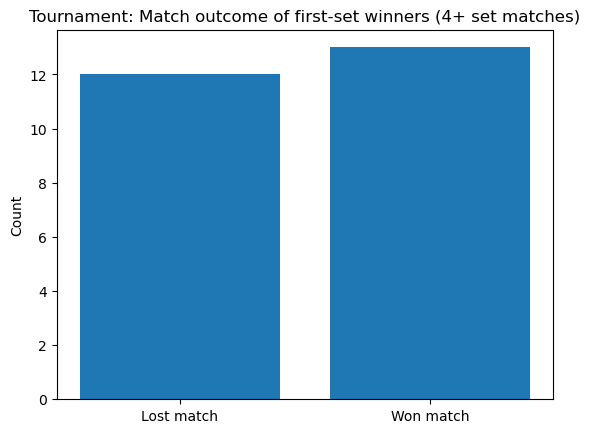

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def eda1_first_set_effect(df_in, label):
    df = df_in.copy()
    df["first_set_winner"] = np.where(df["s1_1"] > df["s2_1"], "team1", "team2")
    df["match_winner"] = np.where(df["sets_1"] > df["sets_2"], "team1", "team2")
    df["first_set_match_win"] = (df["first_set_winner"] == df["match_winner"]).astype(int)
    prob = df["first_set_match_win"].mean()
    print(f"\nEDA 1 — {label}")
    print("P(first set winner wins match) =", round(prob, 4))
    counts = df["first_set_match_win"].value_counts().sort_index()
    plt.figure()
    plt.bar(["Lost match", "Won match"], counts.values)
    plt.title(f"{label}: Match outcome of first-set winners (4+ set matches)")
    plt.ylabel("Count")
    plt.show()

    return df

df_competitive = eda1_first_set_effect(df_competitive, "Regular Season")
df2_competitive = eda1_first_set_effect(df2_competitive, "Tournament")

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Data Collection:
The datasets used in this project contains match results from NCAA Division 1 women's volleyball during the 2019 season and postseason. Because the data describes sporting events rather than individual's private information, there are no direct concerns regarding informed consent or personal informatiuon. The dataset includes team names, match locations, set scores, and attendance, none of which identify individual atheles or fans.

However bias may still exist. The dataset only includes matches from the 2019 season/postseason which means our analyssi may not generalize to other seasons or different levels of competition. Also, the attendance data may be inconsistently reported across stadiums, which could introduce measurement bias.

Data Storage and Security:
The dataset is stored locally within the project repository in the data/00-raw directory and processed versions are saved in data/02-processed. Because the dataset does not contain personal information, there are minimal risks related to data security or privacy. Nevertheless, maintaining a clear workflow and version control ensures that the analysis is reproducible and that modifications to the dataset are documented.

Analysis Considerations:
One potential limitation of our analysis is that the dataset does not include variables related to team skill level, rankings, conference strength, injuries, or coaching strategies. These factors may influence both the outcome of the first set and the final match result. As a result, correlations observed in the analysis should not be interpreted as causal relationships.

## Team Expectations 

Team Expectation 1 For communication, we will mainly use Instagram, and we expect response times to be around 24 hours.

Team Expectation 2 We expect to provide and receive polite feedback from our group members.

Team Expectation 3 We divided up tasks evenly throughout the proposal, but it is subject to change as we work on the project.

Team Expectation 4 If anyone is falling behind and or can't meet a certain deadline, we all agreed that they need to notify the group at least a day before.

## Project Timeline Proposal

Week 1:
We finalized our research question and identified the datasets we would use. We chose the 2019 NCAA Division I women’s volleyball regular season and tournament match datasets.

Week 2:
We loaded both datasets into Python and performed basic data cleaning. We removed rows with missing site values and created a total_sets variable to calculate the total number of sets played in each match.

Week 3:
We filtered the datasets to include only competitive matches (matches with 4 or more sets). We also began exploratory data analysis by determining the first set winner and the overall match winner.

Week 4:
We will continue our exploratory analysis by examining the relationship between first set winners, match outcomes, and match competitiveness.

Week 5:
We will finalize our analysis, create visualizations, and write the final report explaining our results.